##fully connected neural network

In [17]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional
import copy

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [19]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [20]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://aflow.org/API/aflux/"  # placeholder

SELECT = ",".join([
    "compound",
    "auid",
    "positions_fractional",
    "lattice_vectors",
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
    "agl_thermal_conductivity_300K",
])

PER_PAGE = 500
MAX_PAGES = 2000

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "spacegroup_relax",
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]



In [21]:

KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

GLOBAL_TEST_RATIO = 0.1
GLOBAL_VAL_RATIO = 0.1

GLOBAL_EPOCHS = 10
GLOBAL_BATCH_SIZE = 32
GLOBAL_LR = 1e-3

GLOBAL_MODEL_SAVE_PATH = "best_global_only_mlp.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [22]:
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "ael_debye_temperature(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cp_300K(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "agl_vibrational_entropy_300K_atom(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 1000
MAX_PAGES = 10   # safety cap: 300k entries max; adjust if needed

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [23]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [24]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [25]:
df = fetch_all_aflow()


Paging AFLOW:  60%|██████    | 6/10 [00:07<00:04,  1.19s/it]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),ael_debye_temperature(*),agl_debye(*),agl_acoustic_debye(*),agl_gruneisen(*),agl_heat_capacity_Cp_300K(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),agl_vibrational_entropy_300K_atom(*),positions_fractional(*),geometry(*),$format(json),$paging(7,1000)


In [26]:
# ============================================================
# Build dataframe for global-only model
# ============================================================
global_cols = GLOBAL_FEATURE_KEYS + [TARGET_KEY, "compound"]

global_df = df[[c for c in global_cols if c in df.columns]].copy()

global_df = global_df.dropna(subset=[TARGET_KEY])

for c in GLOBAL_FEATURE_KEYS:
    if c not in global_df.columns:
        global_df[c] = 0.0

global_df[GLOBAL_FEATURE_KEYS] = global_df[GLOBAL_FEATURE_KEYS].apply(
    pd.to_numeric,
    errors="coerce"
)

global_df[GLOBAL_FEATURE_KEYS] = global_df[GLOBAL_FEATURE_KEYS].fillna(0.0)

global_df["target_log"] = np.log1p(global_df[TARGET_KEY].astype(float))

In [27]:
# ============================================================
# Train / val / test split
# ============================================================
idx = list(range(len(global_df)))
random.shuffle(idx)

n_total = len(idx)
n_test = max(1, int(GLOBAL_TEST_RATIO * n_total))
n_val = max(1, int(GLOBAL_VAL_RATIO * n_total))
n_train = n_total - n_val - n_test

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train+n_val]
test_idx = idx[n_train+n_val:]

train_df = global_df.iloc[train_idx].reset_index(drop=True)
val_df   = global_df.iloc[val_idx].reset_index(drop=True)
test_df  = global_df.iloc[test_idx].reset_index(drop=True)

In [28]:
# ============================================================
# Feature scaling for global parameters
# ============================================================
x_train = train_df[GLOBAL_FEATURE_KEYS].values.astype(np.float32)
x_val   = val_df[GLOBAL_FEATURE_KEYS].values.astype(np.float32)
x_test  = test_df[GLOBAL_FEATURE_KEYS].values.astype(np.float32)

y_train = train_df["target_log"].values.astype(np.float32)
y_val   = val_df["target_log"].values.astype(np.float32)
y_test  = test_df["target_log"].values.astype(np.float32)

x_mu = x_train.mean(axis=0)
x_std = x_train.std(axis=0)
x_std[x_std < 1e-12] = 1.0

x_train_scaled = (x_train - x_mu) / x_std
x_val_scaled   = (x_val - x_mu) / x_std
x_test_scaled  = (x_test - x_mu) / x_std

In [29]:
# ============================================================
# Build torch datasets
# ============================================================
train_x = torch.tensor(x_train_scaled, dtype=torch.float32)
val_x   = torch.tensor(x_val_scaled, dtype=torch.float32)
test_x  = torch.tensor(x_test_scaled, dtype=torch.float32)

train_y = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
val_y   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
test_y  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_dataset = torch.utils.data.TensorDataset(train_x, train_y)
val_dataset   = torch.utils.data.TensorDataset(val_x, val_y)
test_dataset  = torch.utils.data.TensorDataset(test_x, test_y)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=GLOBAL_BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=GLOBAL_BATCH_SIZE, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=GLOBAL_BATCH_SIZE, shuffle=False)

In [30]:
# ============================================================
# Define global-only MLP
# ============================================================
class GlobalMLP(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, x):
        return self.net(x)

In [31]:
# ============================================================
# Train global-only model
# ============================================================
def train_global_model(train_loader, val_loader, in_dim, epochs=100, lr=1e-3):

    model = GlobalMLP(in_dim=in_dim, hidden=64).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {"train": [], "val": []}

    best_val = float("inf")
    best_state = None

    for epoch in range(epochs):

        model.train()
        train_loss_sum = 0.0

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            pred = model(xb)
            loss = loss_fn(pred, yb)

            loss.backward()
            opt.step()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / len(train_loader)

        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                val_loss_sum += loss_fn(pred, yb).item()

        val_loss = val_loss_sum / len(val_loader)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:

            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    torch.save(best_state, GLOBAL_MODEL_SAVE_PATH)

    return model, history

In [32]:
# ============================================================
# Train model
# ============================================================
global_model, global_history = train_global_model(
    train_loader=train_loader,
    val_loader=val_loader,
    in_dim=len(GLOBAL_FEATURE_KEYS),
    epochs=GLOBAL_EPOCHS,
    lr=GLOBAL_LR
)

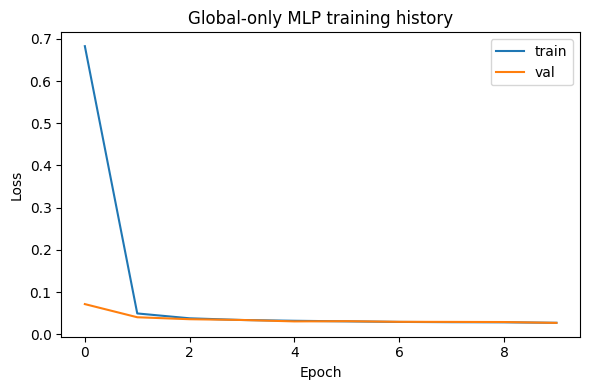

In [33]:
# ============================================================
# Plot training history
# ============================================================
plt.figure(figsize=(6, 4))

plt.plot(global_history["train"], label="train")
plt.plot(global_history["val"], label="val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Global-only MLP training history")

plt.legend()

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Evaluate global-only model
# ============================================================
global_model.load_state_dict(torch.load(GLOBAL_MODEL_SAVE_PATH))

global_model.eval()

true = []
pred = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        p = global_model(xb).view(-1).cpu().numpy()
        y = yb.view(-1).cpu().numpy()

        true.append(y)
        pred.append(p)

true = np.concatenate(true)
pred = np.concatenate(pred)

In [37]:
# ============================================================
# Metrics
# ============================================================
global_metrics_df = pd.DataFrame([{
    "MAE_log": mean_absolute_error(true, pred),
    "RMSE_log": np.sqrt(mean_squared_error(true, pred)),
    "R2_log": r2_score(true, pred),
    "MAE_kappa": mean_absolute_error(np.expm1(true), np.expm1(pred)),
    "RMSE_kappa": np.sqrt(mean_squared_error(np.expm1(true), np.expm1(pred))),
    "R2_kappa": r2_score(np.expm1(true), np.expm1(pred))
}])

global_metrics_df

,MAE_log,RMSE_log,R2_log,MAE_kappa,RMSE_kappa,R2_kappa
0,0.126931,0.192198,0.947991,1.079538,2.430221,0.960068


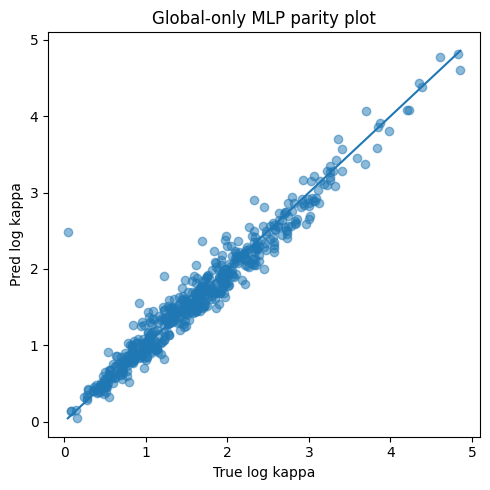

In [38]:
# ============================================================
# Parity plot
# ============================================================
plt.figure(figsize=(5, 5))

plt.scatter(true, pred, alpha=0.5)

lo = min(true.min(), pred.min())
hi = max(true.max(), pred.max())

plt.plot([lo, hi], [lo, hi])

plt.xlabel("True log kappa")
plt.ylabel("Pred log kappa")

plt.title("Global-only MLP parity plot")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# Save outputs
# ============================================================
global_history_df = pd.DataFrame({
    "epoch": np.arange(1, len(global_history["train"]) + 1),
    "train_loss": global_history["train"],
    "val_loss": global_history["val"]
})

global_pred_df = pd.DataFrame({
    "compound": test_df["compound"].values,
    "true_log_kappa": true,
    "pred_log_kappa": pred,
    "true_kappa": np.expm1(true),
    "pred_kappa": np.expm1(pred),
    "abs_error_log": np.abs(true - pred)
})

global_history_df.to_csv("global_only_history.csv", index=False)
global_pred_df.to_csv("global_only_predictions.csv", index=False)
global_metrics_df.to_csv("global_only_metrics.csv", index=False)